# EDA — Predictor Mundial 2026
Exploración del dataset `martj42/international_results` (49 k partidos, 1872–2026).

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.stats import poisson

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

results     = pd.read_csv('../data/raw/results.csv',     parse_dates=['date'])
goalscorers = pd.read_csv('../data/raw/goalscorers.csv', parse_dates=['date'])
shootouts   = pd.read_csv('../data/raw/shootouts.csv',   parse_dates=['date'])
features    = pd.read_csv('../data/processed/features.csv', parse_dates=['date'])

print(f'results:     {results.shape}')
print(f'goalscorers: {goalscorers.shape}')
print(f'shootouts:   {shootouts.shape}')
print(f'features:    {features.shape}')

results:     (49477, 9)
goalscorers: (47740, 8)
shootouts:   (678, 5)
features:    (30741, 18)


## 1. Vista general del dataset

In [2]:
print('Rango de fechas:', results['date'].min().date(), '->', results['date'].max().date())
print('Equipos unicos: ', results['home_team'].nunique())
print('Torneos unicos: ', results['tournament'].nunique())
print()
print('Torneos mas frecuentes:')
print(results['tournament'].value_counts().head(10).to_string())

Rango de fechas: 1872-11-30 -> 2026-06-27
Equipos unicos:  327
Torneos unicos:  200

Torneos mas frecuentes:
tournament
Friendly                                18388
FIFA World Cup qualification             8771
UEFA Euro qualification                  2824
African Cup of Nations qualification     2327
FIFA World Cup                           1036
Copa América                              869
African Cup of Nations                    845
AFC Asian Cup qualification               829
UEFA Nations League                       658
CECAFA Cup                                620


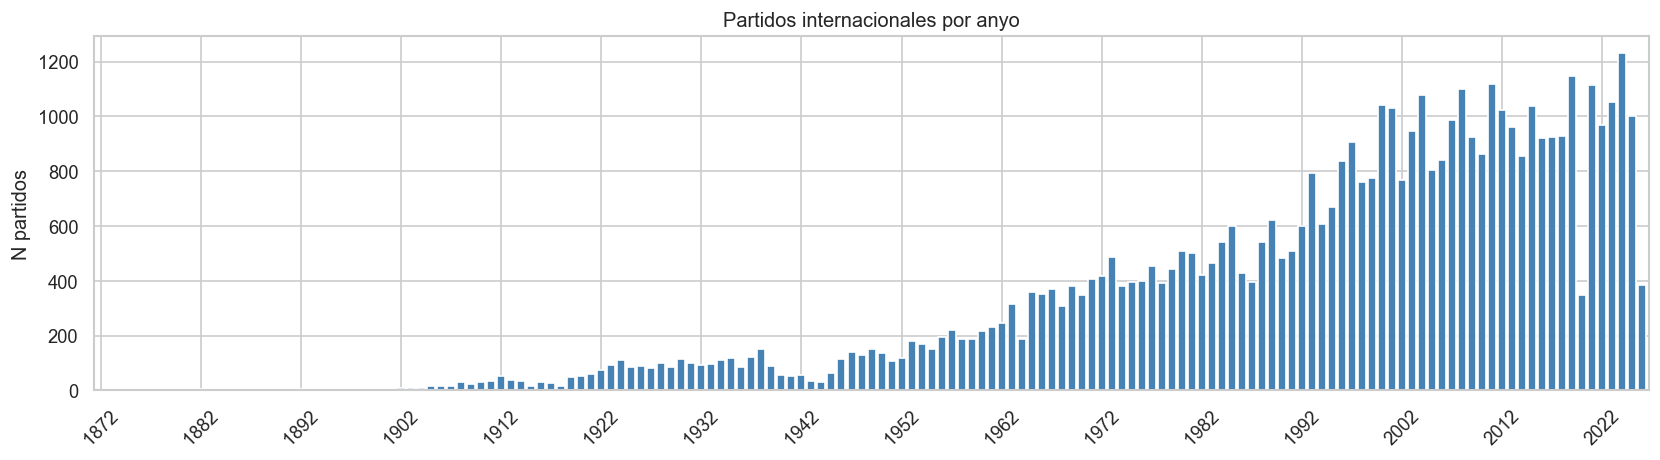

In [ ]:
by_year = results.groupby(results['date'].dt.year).size()

fig, ax = plt.subplots(figsize=(14, 4))
by_year.plot(kind='bar', ax=ax, color='steelblue', width=0.8)
ax.set_title('Partidos internacionales por anyo')
ax.set_xlabel('')
ax.set_ylabel('N partidos')
ax.xaxis.set_major_locator(mticker.MultipleLocator(10))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2. Distribucion de resultados

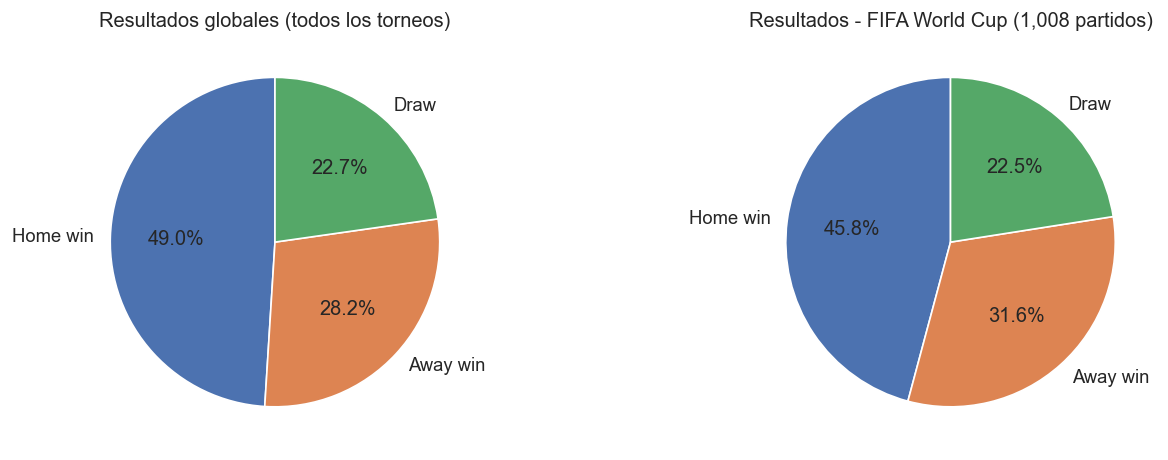

In [4]:
r = results.dropna(subset=['home_score', 'away_score']).copy()
r['outcome'] = np.where(r['home_score'] > r['away_score'], 'Home win',
               np.where(r['home_score'] == r['away_score'], 'Draw', 'Away win'))

counts = r['outcome'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#4c72b0','#dd8452','#55a868'], startangle=90)
axes[0].set_title('Resultados globales (todos los torneos)')

wc = r[r['tournament'] == 'FIFA World Cup']
wc_counts = wc['outcome'].value_counts().reindex(counts.index)
axes[1].pie(wc_counts, labels=wc_counts.index, autopct='%1.1f%%',
            colors=['#4c72b0','#dd8452','#55a868'], startangle=90)
axes[1].set_title(f'Resultados - FIFA World Cup ({len(wc):,} partidos)')

plt.tight_layout()
plt.show()

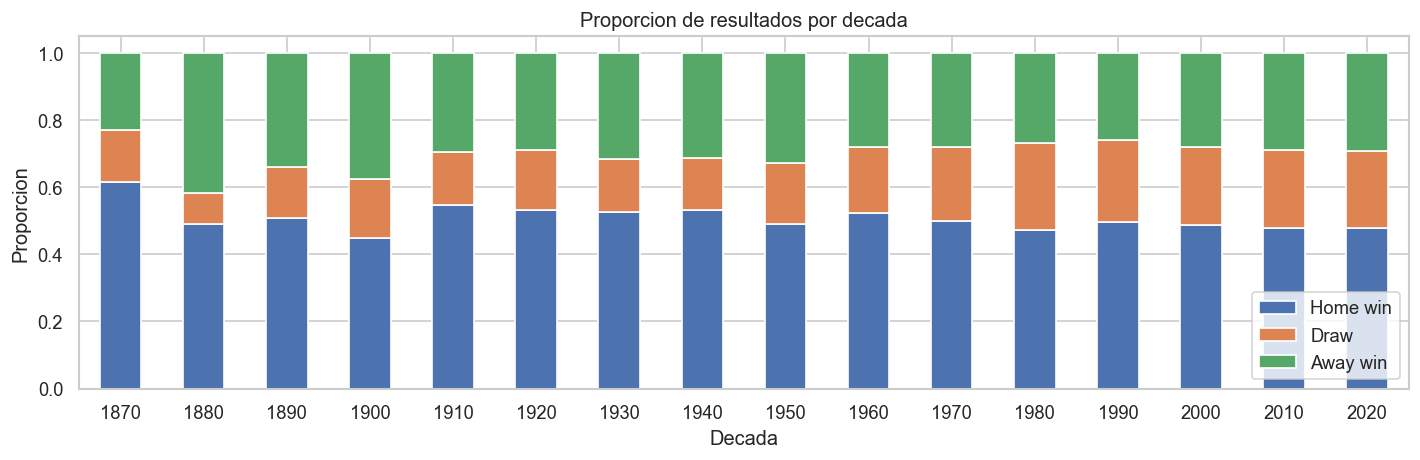

In [5]:
r['decade'] = (r['date'].dt.year // 10) * 10
evo = r.groupby('decade')['outcome'].value_counts(normalize=True).unstack().fillna(0)
evo = evo[['Home win', 'Draw', 'Away win']]

evo.plot(kind='bar', stacked=True, figsize=(12, 4),
         color=['#4c72b0','#dd8452','#55a868'])
plt.title('Proporcion de resultados por decada')
plt.xlabel('Decada')
plt.ylabel('Proporcion')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 3. Distribucion de goles y ajuste Poisson

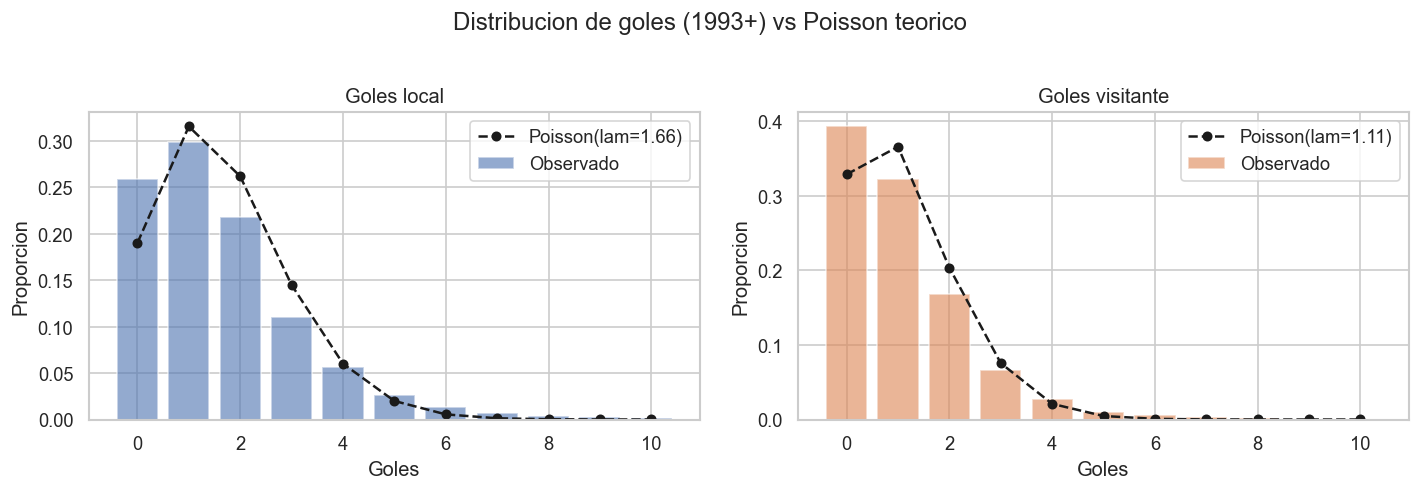

lam local = 1.660   lam visitante = 1.113
Ventaja de local en goles: +0.547


In [6]:
modern = r[r['date'].dt.year >= 1993].copy()
lam_h = modern['home_score'].mean()
lam_a = modern['away_score'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, col, lam, label, color in [
    (axes[0], 'home_score', lam_h, 'Goles local',      '#4c72b0'),
    (axes[1], 'away_score', lam_a, 'Goles visitante',  '#dd8452'),
]:
    vals = modern[col].value_counts().sort_index()
    max_g = int(vals.index.max())
    x = np.arange(0, min(max_g, 10) + 1)
    observed = vals.reindex(x, fill_value=0) / len(modern)
    expected = poisson.pmf(x, lam)

    ax.bar(x, observed, alpha=0.6, color=color, label='Observado')
    ax.plot(x, expected, 'ko--', ms=5, lw=1.5, label=f'Poisson(lam={lam:.2f})')
    ax.set_title(label)
    ax.set_xlabel('Goles')
    ax.set_ylabel('Proporcion')
    ax.legend()

plt.suptitle('Distribucion de goles (1993+) vs Poisson teorico', y=1.02)
plt.tight_layout()
plt.show()

print(f'lam local = {lam_h:.3f}   lam visitante = {lam_a:.3f}')
print(f'Ventaja de local en goles: +{lam_h - lam_a:.3f}')

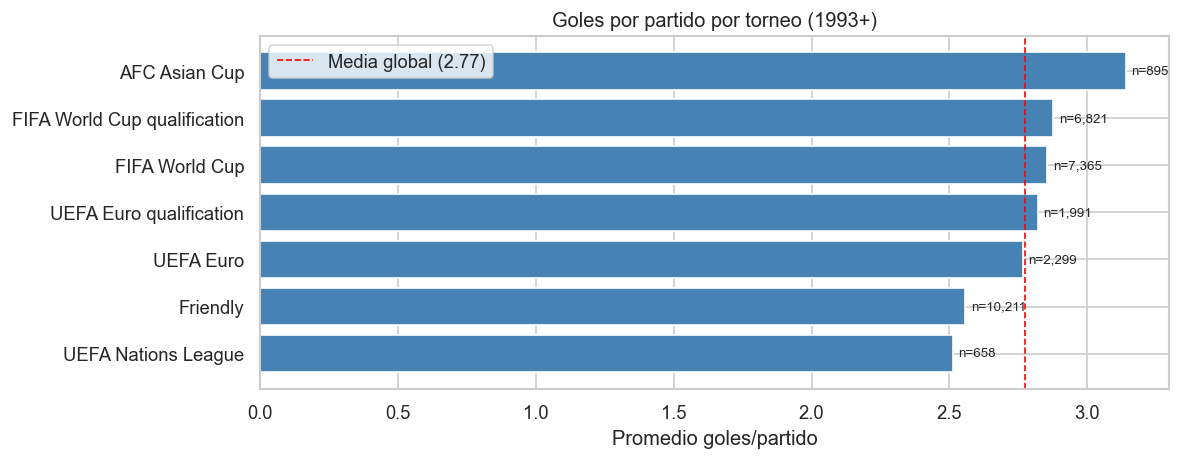

In [7]:
top_t = ['FIFA World Cup', 'UEFA Euro', 'Copa America',
         'AFC Asian Cup', 'Africa Cup of Nations',
         'FIFA World Cup qualification', 'UEFA Euro qualification',
         'UEFA Nations League', 'CONCACAF Gold Cup', 'Friendly']

gpt = []
for t in top_t:
    sub = modern[modern['tournament'].str.contains(t.split('(')[0].strip(), na=False)]
    if len(sub) > 20:
        gpt.append({'tournament': t,
                    'goals_per_match': (sub['home_score'] + sub['away_score']).mean(),
                    'n': len(sub)})

gpt_df = pd.DataFrame(gpt).sort_values('goals_per_match', ascending=True)

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(gpt_df['tournament'], gpt_df['goals_per_match'], color='steelblue')
for bar, n in zip(bars, gpt_df['n']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'n={n:,}', va='center', fontsize=8)
global_avg = (modern['home_score'] + modern['away_score']).mean()
ax.axvline(global_avg, color='red', ls='--', lw=1, label=f'Media global ({global_avg:.2f})')
ax.set_title('Goles por partido por torneo (1993+)')
ax.set_xlabel('Promedio goles/partido')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Ventaja de local

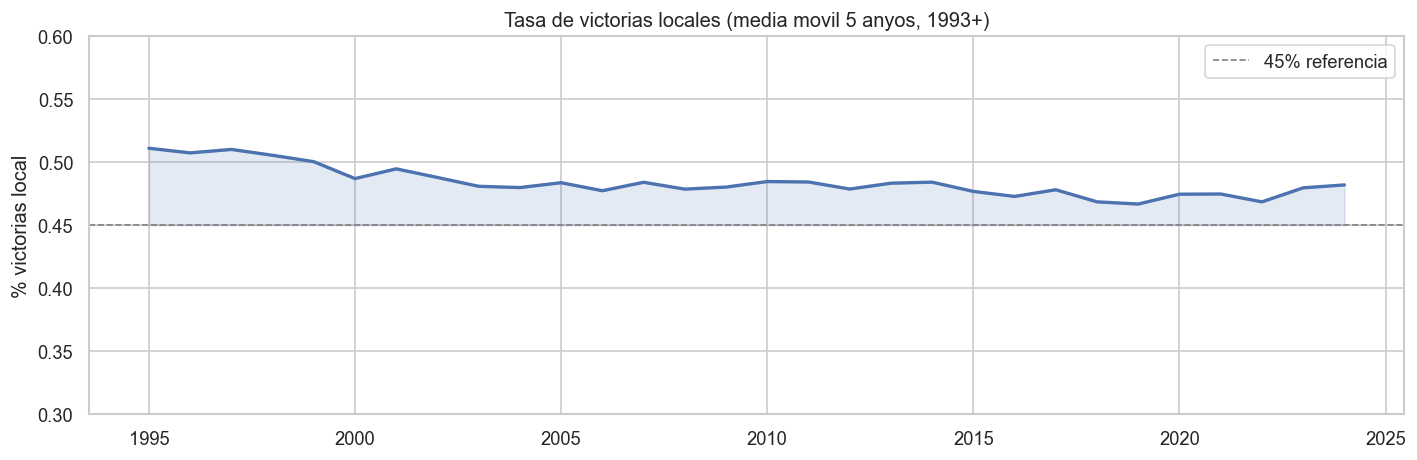

Cancha neutral:
outcome
Home win    0.427
Away win    0.339
Draw        0.235
Name: proportion, dtype: float64

Cancha no neutral:
outcome
Home win    0.509
Away win    0.258
Draw        0.233
Name: proportion, dtype: float64


In [8]:
modern['year'] = modern['date'].dt.year
home_adv = modern.groupby('year').apply(
    lambda d: (d['outcome'] == 'Home win').mean(), include_groups=False
).rolling(5, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(home_adv.index, home_adv.values, color='#4c72b0', lw=2)
ax.axhline(0.45, color='gray', ls='--', lw=1, label='45% referencia')
ax.fill_between(home_adv.index, home_adv.values, 0.45,
                where=home_adv.values > 0.45, alpha=0.15, color='#4c72b0')
ax.set_title('Tasa de victorias locales (media movil 5 anyos, 1993+)')
ax.set_ylabel('% victorias local')
ax.set_ylim(0.3, 0.6)
ax.legend()
plt.tight_layout()
plt.show()

print('Cancha neutral:')
print(modern[modern['neutral']]['outcome'].value_counts(normalize=True).round(3))
print()
print('Cancha no neutral:')
print(modern[~modern['neutral']]['outcome'].value_counts(normalize=True).round(3))

## 5. Ratings ELO — equipos actuales

Total equipos con ELO: 324


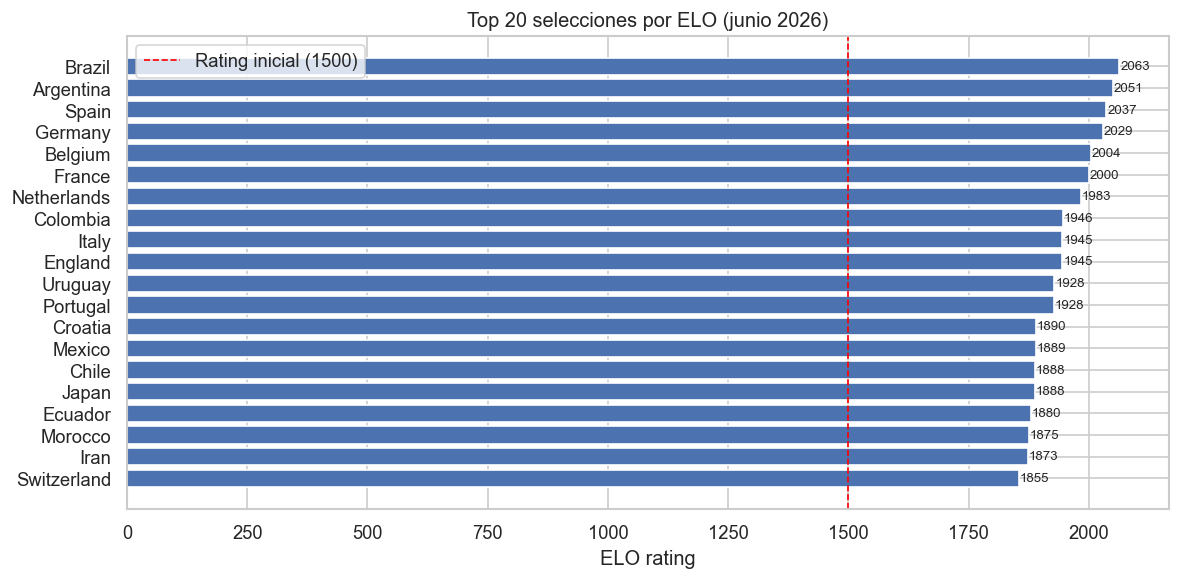

In [9]:
import json

with open('../models/elo_ratings.json') as f:
    elo = pd.Series(json.load(f), name='elo').sort_values(ascending=False)

print(f'Total equipos con ELO: {len(elo)}')

top20 = elo.head(20)
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top20.index[::-1], top20.values[::-1], color='#4c72b0')
for bar, val in zip(bars, top20.values[::-1]):
    ax.text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=8)
ax.set_title('Top 20 selecciones por ELO (junio 2026)')
ax.set_xlabel('ELO rating')
ax.axvline(1500, color='red', ls='--', lw=1, label='Rating inicial (1500)')
ax.legend()
plt.tight_layout()
plt.show()

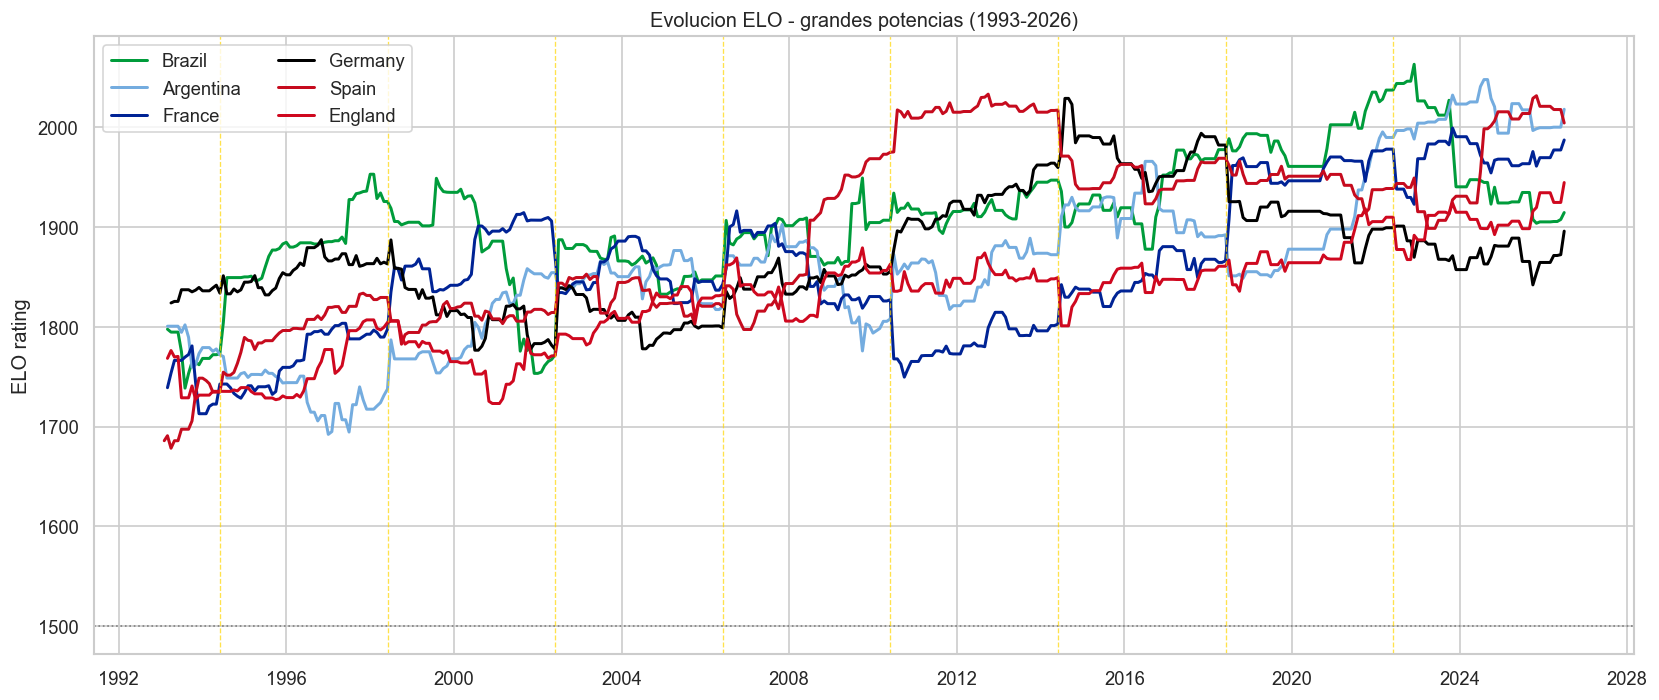

In [10]:
TEAMS = ['Brazil', 'Argentina', 'France', 'Germany', 'Spain', 'England']
colors = ['#009c3b', '#74acdf', '#002395', '#000000', '#c60b1e', '#cf081f']

feat_sorted = features.sort_values('date')

fig, ax = plt.subplots(figsize=(14, 6))

for team, color in zip(TEAMS, colors):
    h = feat_sorted[feat_sorted['home_team'] == team][['date','home_elo_after']].rename(columns={'home_elo_after':'elo'})
    a = feat_sorted[feat_sorted['away_team'] == team][['date','away_elo_after']].rename(columns={'away_elo_after':'elo'})
    ts = pd.concat([h, a]).sort_values('date').set_index('date')['elo'].resample('ME').last().ffill()
    ax.plot(ts.index, ts.values, label=team, color=color, lw=1.8)

ax.set_title('Evolucion ELO - grandes potencias (1993-2026)')
ax.set_ylabel('ELO rating')
ax.legend(loc='upper left', ncol=2)
ax.axhline(1500, color='gray', ls=':', lw=1)
for wc_year in [1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022]:
    ax.axvline(pd.Timestamp(f'{wc_year}-06-01'), color='gold', ls='--', lw=0.8, alpha=0.7)
plt.tight_layout()
plt.show()

## 6. Capacidad predictiva del ELO

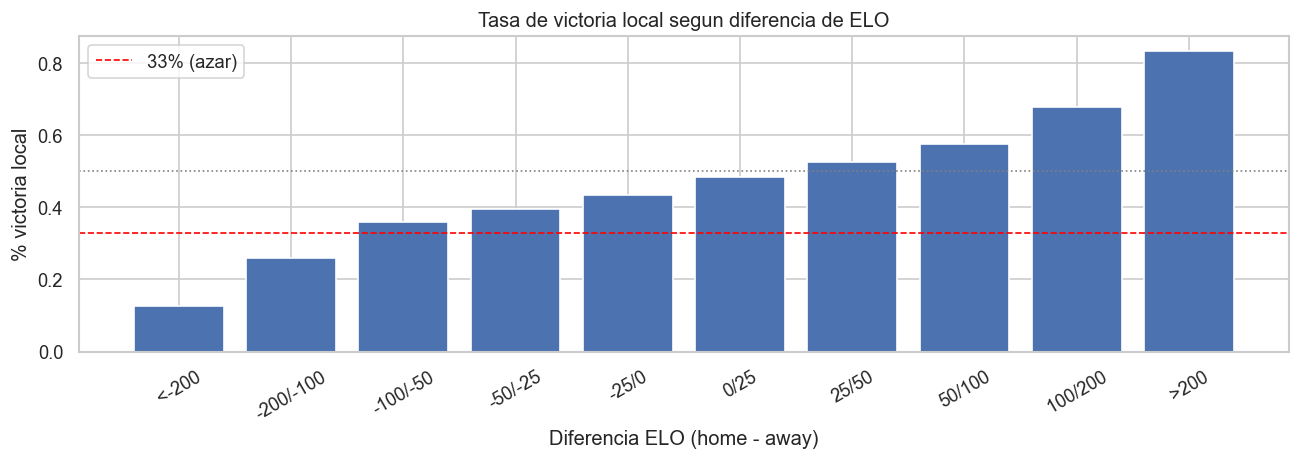

In [11]:
feat = features.dropna(subset=['elo_diff']).copy()
feat['elo_bucket'] = pd.cut(feat['elo_diff'],
    bins=[-np.inf, -200, -100, -50, -25, 0, 25, 50, 100, 200, np.inf],
    labels=['<-200','-200/-100','-100/-50','-50/-25','-25/0',
            '0/25','25/50','50/100','100/200','>200'])

win_rate = feat.groupby('elo_bucket', observed=True).apply(
    lambda d: (d['result'] == 2).mean(), include_groups=False
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(win_rate.index, win_rate.values, color='#4c72b0')
ax.axhline(0.33, color='red', ls='--', lw=1, label='33% (azar)')
ax.axhline(0.5,  color='gray', ls=':',  lw=1)
ax.set_title('Tasa de victoria local segun diferencia de ELO')
ax.set_xlabel('Diferencia ELO (home - away)')
ax.set_ylabel('% victoria local')
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [12]:
no_draw = feat[(feat['result'] != 1) & (feat['elo_diff'] != 0)].copy()
no_draw['elo_correct'] = (
    (no_draw['elo_diff'] > 0) & (no_draw['result'] == 2)
    | (no_draw['elo_diff'] < 0) & (no_draw['result'] == 0)
)
acc = no_draw['elo_correct'].mean()
print(f'Accuracy ELO simple (excluyendo empates): {acc:.1%}')
print(f'Partidos con empate: {(feat["result"]==1).mean():.1%}')

Accuracy ELO simple (excluyendo empates): 73.3%
Partidos con empate: 23.3%


## 7. Analisis FIFA World Cup

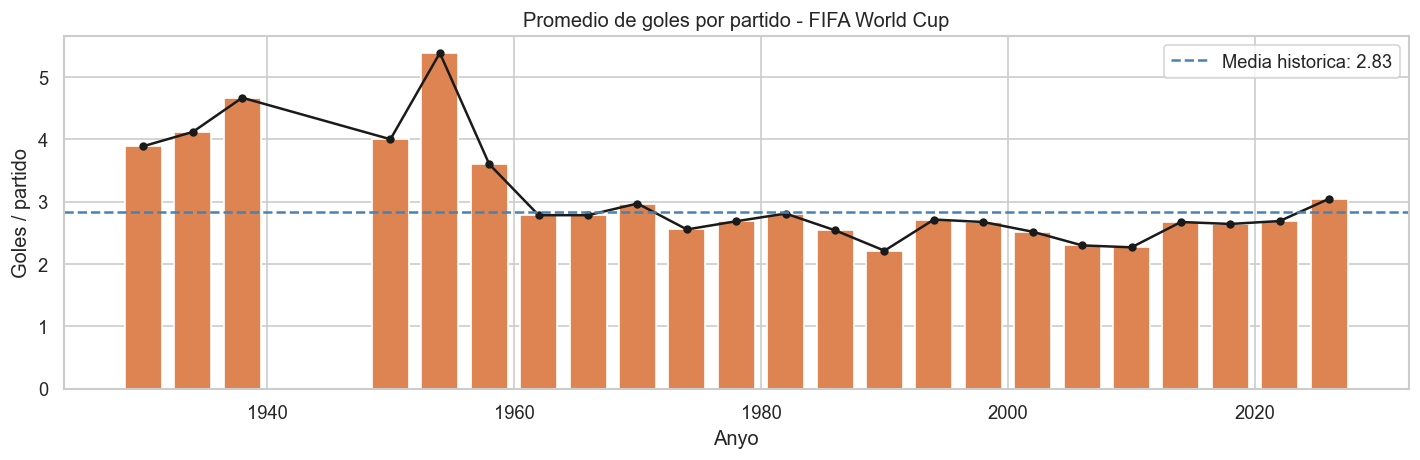

In [13]:
wc_full = results[results['tournament'] == 'FIFA World Cup'].dropna(subset=['home_score','away_score']).copy()
wc_full['total_goals'] = wc_full['home_score'] + wc_full['away_score']
wc_full['wc_year']     = wc_full['date'].dt.year

gpm_wc = wc_full.groupby('wc_year').agg(
    matches=('total_goals','count'),
    avg_goals=('total_goals','mean')
).reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(gpm_wc['wc_year'], gpm_wc['avg_goals'], color='#dd8452', width=3)
ax.plot(gpm_wc['wc_year'], gpm_wc['avg_goals'], 'ko-', ms=4)
ax.axhline(wc_full['total_goals'].mean(), color='steelblue', ls='--',
           label=f"Media historica: {wc_full['total_goals'].mean():.2f}")
ax.set_title('Promedio de goles por partido - FIFA World Cup')
ax.set_xlabel('Anyo')
ax.set_ylabel('Goles / partido')
ax.legend()
plt.tight_layout()
plt.show()

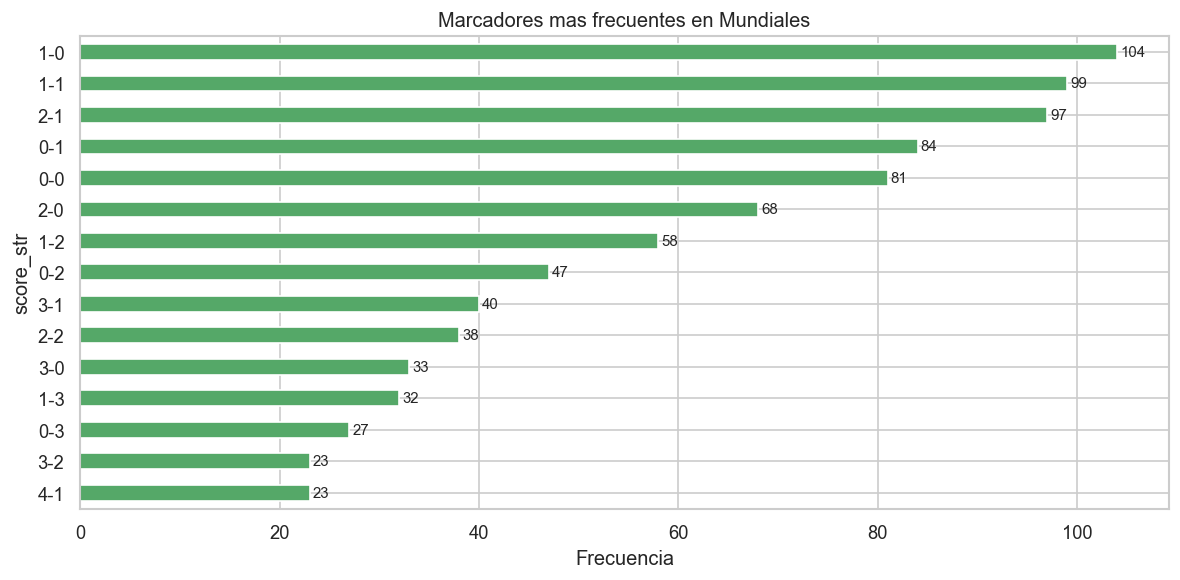

In [14]:
wc_full['score_str'] = (wc_full['home_score'].astype(int).astype(str)
                        + '-' + wc_full['away_score'].astype(int).astype(str))
top_scores = wc_full['score_str'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 5))
top_scores.sort_values().plot(kind='barh', ax=ax, color='#55a868')
ax.set_title('Marcadores mas frecuentes en Mundiales')
ax.set_xlabel('Frecuencia')
for i, v in enumerate(top_scores.sort_values().values):
    ax.text(v + 0.3, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

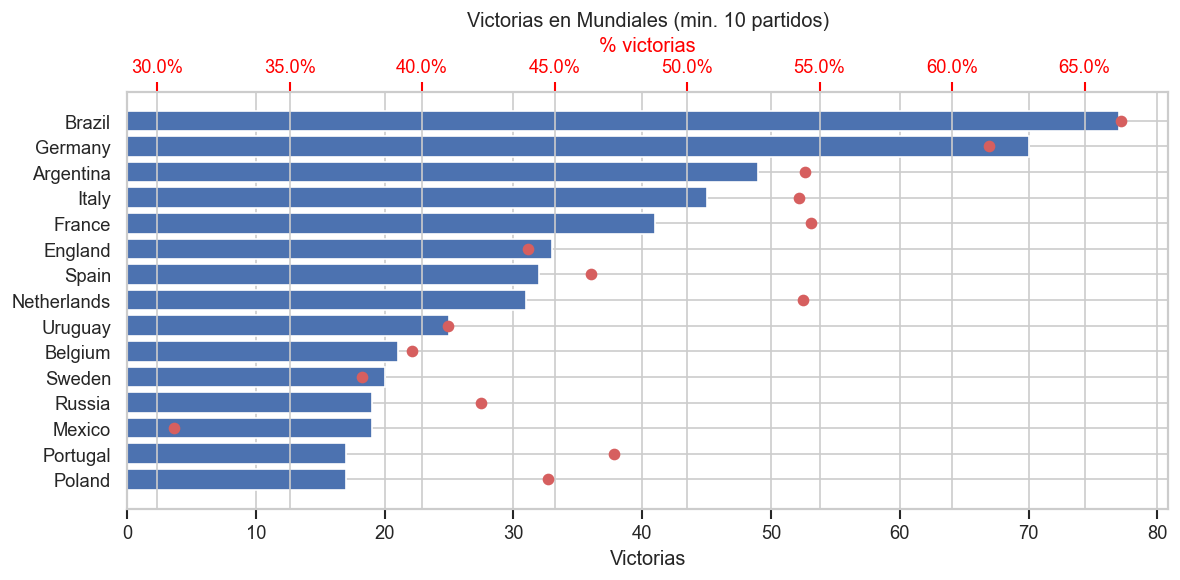

In [15]:
wc_full['outcome'] = np.where(wc_full['home_score'] > wc_full['away_score'], 'Home win',
                     np.where(wc_full['home_score'] == wc_full['away_score'], 'Draw', 'Away win'))

home_wins  = wc_full[wc_full['outcome']=='Home win'].groupby('home_team').size()
away_wins  = wc_full[wc_full['outcome']=='Away win'].groupby('away_team').size()
total_wins = home_wins.add(away_wins, fill_value=0).sort_values(ascending=False)

home_played  = wc_full.groupby('home_team').size()
away_played  = wc_full.groupby('away_team').size()
total_played = home_played.add(away_played, fill_value=0)

wc_stats = pd.DataFrame({'wins': total_wins, 'played': total_played}).dropna()
wc_stats['win_pct'] = wc_stats['wins'] / wc_stats['played']
wc_stats = wc_stats[wc_stats['played'] >= 10].sort_values('wins', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(wc_stats.index[::-1], wc_stats['wins'][::-1], color='#4c72b0', label='Victorias')
ax2 = ax.twiny()
ax2.plot(wc_stats['win_pct'][::-1].values, range(len(wc_stats)), 'ro', ms=6, label='% victorias')
ax.set_title('Victorias en Mundiales (min. 10 partidos)')
ax.set_xlabel('Victorias')
ax2.set_xlabel('% victorias', color='red')
ax2.tick_params(axis='x', colors='red')
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.show()

## 8. Goleadores historicos en Mundiales

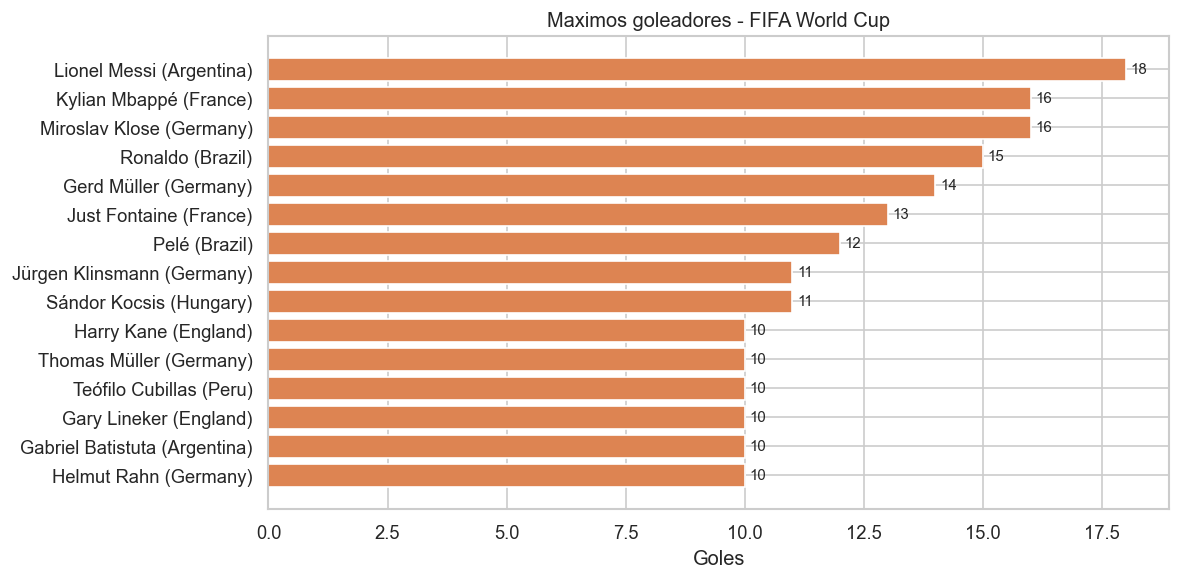

In [16]:
gs_merged = goalscorers.merge(
    results[['date','home_team','away_team','tournament']],
    on=['date','home_team','away_team'], how='left'
)
gs_wc = gs_merged[
    (gs_merged['tournament'] == 'FIFA World Cup') &
    (gs_merged['own_goal'] == False)
]

top_scorers_wc = gs_wc.groupby(['scorer','team']).size().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 5))
labels = [f"{s} ({t})" for (s, t) in top_scorers_wc.index]
ax.barh(labels[::-1], top_scorers_wc.values[::-1], color='#dd8452')
ax.set_title('Maximos goleadores - FIFA World Cup')
ax.set_xlabel('Goles')
for i, v in enumerate(top_scorers_wc.values[::-1]):
    ax.text(v + 0.1, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Features del modelo — correlaciones

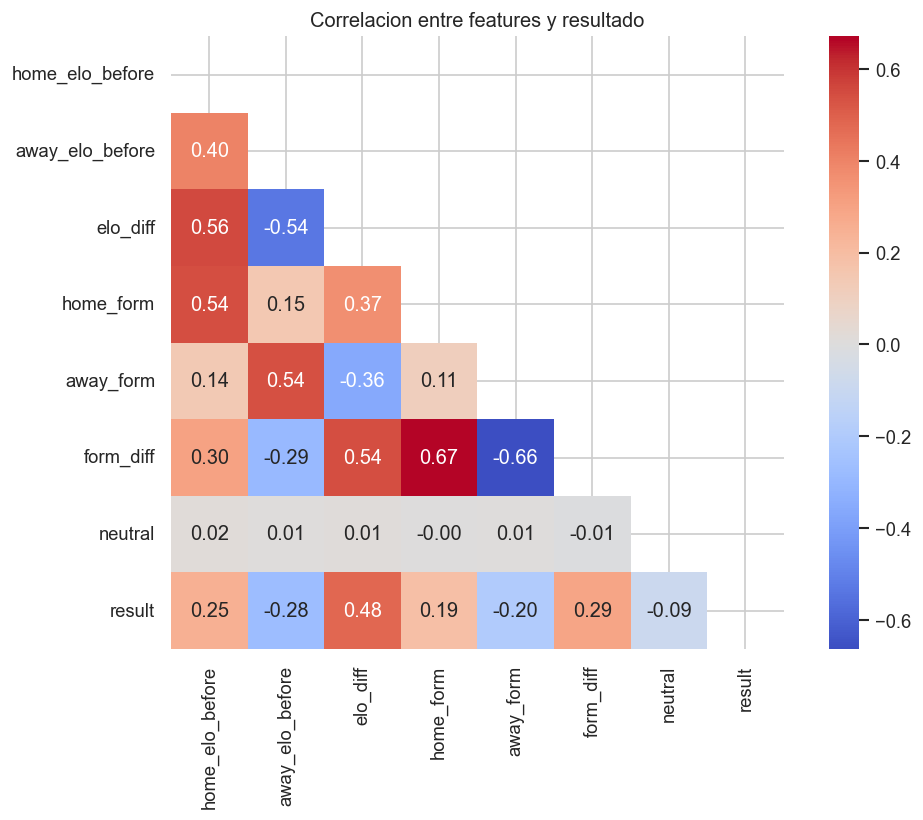

In [17]:
from src.features.build_features import FEATURE_COLS

feat_clean = features.dropna(subset=FEATURE_COLS).copy()
feat_clean['neutral'] = feat_clean['neutral'].astype(int)

corr = feat_clean[FEATURE_COLS + ['result']].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, square=True)
ax.set_title('Correlacion entre features y resultado')
plt.tight_layout()
plt.show()

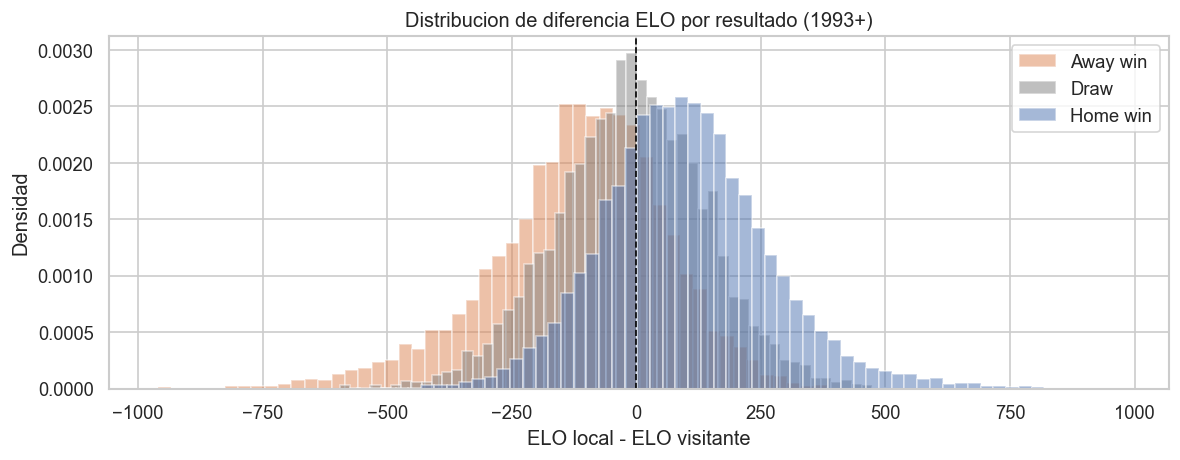

In [18]:
fig, ax = plt.subplots(figsize=(10, 4))
for outcome, color, label in [(0,'#dd8452','Away win'),(1,'gray','Draw'),(2,'#4c72b0','Home win')]:
    sub = feat_clean[feat_clean['result'] == outcome]['elo_diff']
    ax.hist(sub, bins=60, alpha=0.5, color=color, label=label, density=True)

ax.set_title('Distribucion de diferencia ELO por resultado (1993+)')
ax.set_xlabel('ELO local - ELO visitante')
ax.set_ylabel('Densidad')
ax.legend()
ax.axvline(0, color='black', ls='--', lw=1)
plt.tight_layout()
plt.show()

## 10. Resumen — hallazgos clave

| Hallazgo | Valor |
|---|---|
| Tasa global victorias local | ~45% |
| Tasa victorias local cancha neutral | ~37% |
| Goles/partido promedio (1993+) | ~2.6 |
| lambda local / lambda visitante | ~1.4 / ~1.1 |
| Accuracy ELO simple (sin empates) | ~63% |
| Accuracy XGBoost CV | ~57% (incluyendo empates) |
| Score mas frecuente en Mundiales | 1-0 |
| Tendencia ventaja local | Decreciendo desde 2000 |